## IBM ACCOUNT DETAILS

In [2]:
your_api_key = "3Juwo1Ygio37x1My-dFkur481vPpUyRMrzF-WXJQvtU6"
your_crn = "crn:v1:bluemix:public:quantum-computing:us-east:a/5a8ac1c64f0f4d6bb48b2db1e866c970:3ab20cba-7b95-4368-9eeb-845203c07986::"
print(your_api_key)


3Juwo1Ygio37x1My-dFkur481vPpUyRMrzF-WXJQvtU6


In [3]:
from qiskit_ibm_runtime import QiskitRuntimeService

QiskitRuntimeService.save_account(
    channel="ibm_quantum_platform",
    token=your_api_key,
    instance=your_crn,
    name="qamp-2025",
    overwrite=True
)


In [4]:
service = QiskitRuntimeService(name="qamp-2025")
service.saved_accounts()

management.get:WARNING:2025-11-04 10:00:15,853: Loading saved account: qamp-2025


{'qamp-2025': {'channel': 'ibm_quantum_platform',
  'url': 'https://cloud.ibm.com',
  'token': '3Juwo1Ygio37x1My-dFkur481vPpUyRMrzF-WXJQvtU6',
  'instance': 'crn:v1:bluemix:public:quantum-computing:us-east:a/5a8ac1c64f0f4d6bb48b2db1e866c970:3ab20cba-7b95-4368-9eeb-845203c07986::',
  'verify': True,
  'private_endpoint': False}}

## Imports 


In [68]:
from qiskit.circuit import QuantumCircuit
from qiskit.transpiler import generate_preset_pass_manager, PassManager
from qiskit.transpiler.passes.scheduling import ALAPScheduleAnalysis, PadDynamicalDecoupling
from qiskit_ibm_runtime.fake_provider import FakeBrisbane 
from qiskit_ibm_runtime.sampler import SamplerOptions, SamplerV2 as Sampler
from qiskit_ibm_runtime import Batch
from qiskit.visualization import plot_histogram
from qiskit.circuit.library import XGate 
from qiskit.quantum_info import hellinger_fidelity
import numpy as np


## Functions used

In [ ]:
def prepare_ghz(n_qubits:int):
    ## Prepares standard ghz state with measurements on all qubits using measure_all() 
    circuit = QuantumCircuit(n_qubits)
    circuit.h(0)
    for i in range(0, n_qubits-1):
        circuit.cx(i, i+1)

    circuit.measure_all()

    return circuit


def naked_sampler(mode, shots=4096):
    ## Sampler with no error mitigation or supression for any mode (job, batch). ALL OPTIONS ARE DISABLED. 
    options = SamplerOptions(default_shots=shots, dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
    sampler = Sampler(mode=mode, options=options)
    return sampler


def pm_for_backend(bknd, opt_level, seed=42069):
    ## Returns a PassManager from generate_preset_pass_manager for given opt_level and backend(bknd)
    pm = generate_preset_pass_manager(optimization_level=opt_level, backend=bknd, seed_transpiler=seed)
    return pm


def prepare_dd_pm(backend, schedueling_method="alap", seq=[XGate(), XGate()]):
    ## Returns a PassManager for DD with customizable DD sequence and scheduelling method. 
    
    target = backend.target
    pm = PassManager([ALAPScheduleAnalysis(target=target),PadDynamicalDecoupling(target=target, dd_sequence=seq)])
    return pm



def execute_on_hardware(bknd, sampler_pub, iterations=3):
    ## Batch mode execution of quantum circuits on hardware
    with Batch(backend=bknd) as batch:
        job_dict = {}
        for i in range(iterations):
            sampler = naked_sampler(mode=batch, shots=4096)
            job = sampler.run(sampler_pub)
            job_dict.append({str(i):job.job_id()})

    return job_dict

#           0       1       2          3                4                5             6                  7                              8       
# Index  job_id | Qubit | shots | ideal_counts | simulated_counts | no_dd_counts | dd_counts | hellinger_fidelity(ideal) | hellinger_fidelity(simulated)
def store_data(service, id, simulated):
    
    job = service.job(id)
    result = job.result()
    
    # 0 Id
    data_list = [id]
    
    # 1 Qubit
    num_qubits = len(list(result[0].data.meas.get_counts().keys()))
    data_list.append(num_qubits)
    
    # 2 Shots PLEASE KEEP THIS NUMBER AS EVEN
    shots = result[0].data.meas.num_shots
    data_list.append(shots)
    
    # 3 Ideal_counts
    ideal = {'0'*num_qubits:int(shots/2), '1'*num_qubits:int(shots/2)}
    data_list.append(ideal)
    
    # 4 Simulated_counts
    data_list.append(simulated)
    
    # 5 no_dd_counts
    no_dd_counts = result[0].data.meas.get_counts()
    data_list.append(no_dd_counts)
    
    # 6 dd_counts
    dd_counts = result[1].data.meas.get_counts()
    data_list.append(dd_counts)

    # 7 hellinger_fidelity(ideal) and hellinger_fidelity(simulated)
    data_list += get_fidelity_for_ghz(result, simulated, ideal, no_dd_counts, dd_counts)


    return data_list
    





def get_fidelity_for_ghz(result, simulated=dict, ideal=dict, no_dd_counts=dict, dd_counts=dict):

    ## Returns List[List] of hellinger fidelity results. Outer list is of length 2 and contains
    # 0 :- List of len 3 with hellinger fidelity compared to ideal counts. [hellinger_simulated, hellinger_no_dd, hellinger_dd]
    # 1 :- List of len 2 with hellinger fidelity compared to simulated counts. [hellinger_no_dd, hellinger_dd]

    # Calculating hellinger fidelity compared to ideal counts

    hellinger_results = []

    for target_result in [simulated, no_dd_counts, dd_counts]:

        hellinger_results.append(hellinger_fidelity(ideal, target_result))

    # Calculate hellinger fidelity compared to simulated counts

    alt_hellinger_results = []

    for target_result in [no_dd_counts, dd_counts]:
        alt_hellinger_results.append(hellinger_fidelity(simulated, target_result))



    return [hellinger_results, alt_hellinger_results]  




## Testing hardware execution with a test circuit

In [58]:
ghz_test = prepare_ghz(n_qubits=2)
ghz_test.draw()


┌───┐      ░ ┌─┐   
   q_0: ┤ H ├──■───░─┤M├───
        └───┘┌─┴─┐ ░ └╥┘┌─┐
   q_1: ─────┤ X ├─░──╫─┤M├
             └───┘ ░  ║ └╥┘
meas: 2/══════════════╩══╩═
                      0  1

### Transpiling for a real backend : Brisbane

In [8]:
torino = service.backend("ibm_torino")
test_pm = generate_preset_pass_manager(optimization_level=3, seed_transpiler=42069, backend=torino)
test_pm.expanded_stages

('pre_init',
 'init',
 'post_init',
 'pre_layout',
 'layout',
 'post_layout',
 'pre_routing',
 'routing',
 'post_routing',
 'pre_translation',
 'translation',
 'post_translation',
 'pre_optimization',
 'optimization',
 'post_optimization',
 'pre_scheduling',
 'scheduling',
 'post_scheduling')

In [9]:
isa_ghz_test = test_pm.run(ghz_test)
isa_ghz_test.draw()

global phase: 3π/4
          ┌─────────┐┌────┐┌─────────┐                     ░ ┌─┐   
q_0 -> 91 ┤ Rz(π/2) ├┤ √X ├┤ Rz(π/2) ├─■───────────────────░─┤M├───
          ├─────────┤├────┤└┬───────┬┘ │ ┌────┐┌─────────┐ ░ └╥┘┌─┐
q_1 -> 95 ┤ Rz(π/2) ├┤ √X ├─┤ Rz(π) ├──■─┤ √X ├┤ Rz(π/2) ├─░──╫─┤M├
          └─────────┘└────┘ └───────┘    └────┘└─────────┘ ░  ║ └╥┘
  meas: 2/════════════════════════════════════════════════════╩══╩═
                                                              0  1

In [10]:
## Run circuit using job mode
sampler_options = SamplerOptions(default_shots=4096,
                dynamical_decoupling={"enable": False}, twirling={"enable_gates": False, "enable_measure": False})
sampler = Sampler(mode=torino, options=sampler_options)
# job = sampler.run([isa_ghz_test])
# job_id = job.job_id()
# print(job_id)
# result = job.result()
sampler.options

max_execution_time,Unset
default_shots,4096
experimental,Unset
▸environment,EnvironmentOptions
log_level,'WARNING'
job_tags,None
private,False
▸simulator,SimulatorOptions
noise_model,Unset
seed_simulator,Unset
coupling_map,Unset


In [12]:
service = QiskitRuntimeService(name="qamp-2025")
job = service.job('d44e59g7i53s73e507gg')
job_result = job.result()


pub_result = job_result
pub_result[0].data.meas.get_counts()

management.get:WARNING:2025-11-04 10:01:05,008: Loading saved account: qamp-2025


{'11': 1892, '00': 2104, '01': 47, '10': 53}

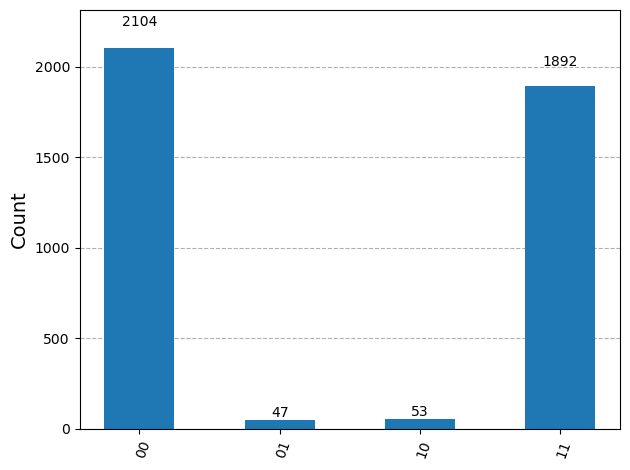

In [13]:

plot_histogram(pub_result[0].data.meas.get_counts())

---
---
---

## Running DD-experiments
- {7, 8, 9, 10}-qubit GHZ circuit with 4096 shots x3 (for averaging).
- Batch mode suitable with PUB as [(isa_ghz), (isa_ghz_dd)] 
- Normal Transpilation (isa_ghz) :- Transpiling for backend with optimization_level = 3
- DD Transpilation (isa_ghz_dd) :- Using a Pass manager for Padding DD with ALAP scheduelling 

In [14]:
service = QiskitRuntimeService(name="qamp-2025")

management.get:WARNING:2025-11-04 10:02:34,943: Loading saved account: qamp-2025


In [15]:
ghz = prepare_ghz(n_qubits=7)
torino = service.backend("ibm_torino")
pm3 = pm_for_backend(torino, 3, 42069)
dd_pm = prepare_dd_pm(backend=torino)
sampler = naked_sampler(mode=torino, shots=4096)

sampler.options

max_execution_time,Unset
default_shots,4096
experimental,Unset
▸environment,EnvironmentOptions
log_level,'WARNING'
job_tags,None
private,False
▸simulator,SimulatorOptions
noise_model,Unset
seed_simulator,Unset
coupling_map,Unset


In [34]:
## Normal transpilaion
isa_ghz = pm3.run(ghz)

## DD Transpilation
isa_ghz_dd = dd_pm.run(isa_ghz)

iterations = 3

## Batch mode
from qiskit_aer import AerSimulator
from qiskit_aer.noise import NoiseModel

noise_model = NoiseModel.from_backend(torino)

aer_backend = AerSimulator(noise_model=noise_model)

with Batch(backend=aer_backend) as batch:
    result_list= []
    for i in range(iterations):
        aer_sampler = naked_sampler(mode=batch, shots=4096)
        aer_job = aer_sampler.run([(isa_ghz), (isa_ghz_dd)])
        print(aer_job.job_id())
        aer_result = aer_job.result()
        result_list.append(aer_result)



/home/aashay/anaconda3/envs/qamp/lib/python3.11/site-packages/qiskit_ibm_runtime/fake_provider/local_service.py:273: UserWarning: Options {'dynamical_decoupling': {'enable': False}, 'twirling': {'enable_gates': False, 'enable_measure': False}} have no effect in local testing mode.
  warnings.warn(f"Options {options_copy} have no effect in local testing mode.")


ab3eefba-4d6a-4e60-bd52-e879195b14d7
2ff1a45d-5961-44ea-ab66-fb5e94f9ccce
684fa76b-6638-482c-9c23-f310d07fef15


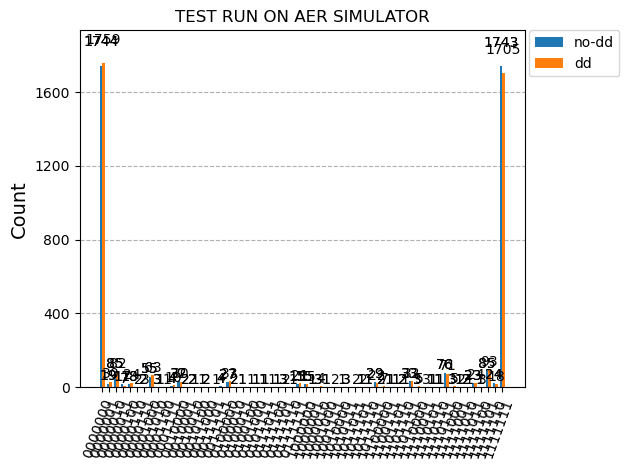

In [53]:
plot_histogram([aer_result[0].data.meas.get_counts(), aer_result[1].data.meas.get_counts()], title="TEST RUN ON AER SIMULATOR", legend=["no-dd", "dd"])

In [54]:
## Ideal simulation ... Only sampling error present

noiseless_backend = AerSimulator()

job = noiseless_backend.run(isa_ghz, shots=4096)
noiseless_result = job.result()

noiseless_counts = noiseless_result.get_counts()
# plot_histogram([noiseless_counts, aer_result[0].data.meas.get_counts(), aer_result[1].data.meas.get_counts()])

In [78]:
data0 = [get_fidelity_for_ghz(result_list[i], noiseless_counts)[0] for i in range(3)]
data1 = [get_fidelity_for_ghz(result_list[i], noiseless_counts)[1] for i in range(3)]

data0_arr = np.array(data0)
data1_arr = np.array(data1)

print(np.mean(data0_arr, axis=0))
print(np.mean(data1_arr, axis=0))

[0.99999404 0.85142538 0.84152894]
[0.85139269 0.84151181]


# Execute on Hardware